# Physics-Informed Neural Network (PINN) for ResidualPhysicsNet

This notebook trains a Physics-Informed Neural Network to learn residual corrections to crop simulator physics.

**Key Insight:** The loss function IS the physics equations. The network learns to predict residuals that make the first-principles equations more accurate.

Rather than collecting empirical data, we generate random (state, action) pairs and enforce that predictions satisfy physics constraints.

## Import Required Libraries

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on: {DEVICE}")

Training on: cuda


## Define Physics Equations

The PINN enforces these first-principles equations as loss constraints:

- **pH dynamics**: $d_{pH} = 0.5 \cdot u_{base} - 0.5 \cdot u_{acid} + 0.001 \cdot biomass$
- **EC dynamics**: $d_{EC} = 0.2 \cdot u_{nutrient} - 0.02 \cdot biomass \cdot VPD / tank\_vol$
- **Air temperature**: $d_{T_{air}} = 0.1 - 1.5 \cdot u_{fan}$
- **Humidity**: $d_{humidity} = 1.0 - 5.0 \cdot u_{fan}$
- **VPD calculation**: $VPD = 0.61078 \cdot e^{(17.27 \cdot T) / (T + 237.3)} - e_a$
- **Biomass growth**: $d_{biomass} = 0.1 \cdot biomass \cdot (1.0 - \min(|VPD - 1.0|, 1.0))$

The ResidualPhysicsNet learns corrections $\delta$ to these equations.

Physics constraints enforced:
- pH must stay in valid range: [4.0, 7.5]
- EC must stay in valid range: [0.1, 3.0]
- VPD must be non-negative
- Nutrient application should increase EC
- Higher fan speed should increase humidity AND decrease temperature

## Build PINN Architecture

In [2]:
class ResidualPhysicsNet(nn.Module):
    """Predicts residual corrections to physics equations"""
    def __init__(self, state_dim=7, action_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, state_dim),
        )

    def forward(self, state, action):
        """
        Input:
          state: tensor of shape (batch, 7) = [pH, EC, water_temp, air_temp, humidity, VPD, biomass]
          action: tensor of shape (batch, 4) = [acid, base, nutrient, fan_speed] (normalized 0-1)
        Output:
          residual_delta: tensor of shape (batch, 7) = residual corrections to state deltas
        """
        x = torch.cat([state, action], dim=-1)
        return self.net(x)

model = ResidualPhysicsNet().to(DEVICE)
print(f"ResidualPhysicsNet: {sum(p.numel() for p in model.parameters())} parameters")

ResidualPhysicsNet: 5383 parameters


## Construct Physics Loss Function

This is the core of the PINN: The loss enforces that predictions satisfy physics equations and constraints.

In [3]:
def calculate_vpd(air_temp, humidity):
    """Calculate vapor pressure deficit"""
    es = 0.61078 * torch.exp((17.27 * air_temp) / (air_temp + 237.3))
    ea = es * (humidity / 100.0)
    return torch.clamp(es - ea, min=0.0)

def physics_loss(state, action, residual_delta):
    """
    Physics-Informed Loss: Constrains network to satisfy physics equations.

    Args:
        state: (batch, 7) = [pH, EC, water_temp, air_temp, humidity, VPD, biomass]
        action: (batch, 4) = [acid, base, nutrient, fan_speed] (0-1 normalized)
        residual_delta: (batch, 7) = NN prediction of residuals

    Returns:
        scalar loss combining all physics constraints
    """
    ph, ec, wt, at, hum, vpd, bio = state.unbind(dim=-1)
    acid, base, nutrient, fan = action.unbind(dim=-1)

    # First-principles physics deltas
    d_ph_fp = (base * 0.5) - (acid * 0.5) + (0.001 * bio)
    uptake = 0.02 * bio * vpd
    d_ec_fp = (nutrient * 0.2) - (uptake / 100.0)
    d_at_fp = 0.1 - (fan * 1.5)
    d_hum_fp = 1.0 - (fan * 5.0)
    stress = torch.abs(vpd - 1.0)
    d_growth_fp = 0.1 * bio * (1.0 - torch.clamp(stress, max=1.0))

    # Extract residual components
    res_ph, res_ec, res_wt, res_at, res_hum, res_vpd, res_bio = residual_delta.unbind(dim=-1)

    # Predicted deltas with residuals (0.05 scaling factor)
    d_ph = d_ph_fp + res_ph * 0.05
    d_ec = d_ec_fp + res_ec * 0.05
    d_at = d_at_fp + res_at * 0.05
    d_hum = d_hum_fp + res_hum * 0.05
    d_bio = d_growth_fp + res_bio * 0.05

    # Updated state after applying deltas
    new_ph = ph + d_ph
    new_ec = ec + d_ec
    new_at = torch.clamp(at + d_at, 0, 50)
    new_hum = torch.clamp(hum + d_hum, 0, 100)
    new_bio = torch.clamp(bio + d_bio, min=0.1)
    new_vpd = calculate_vpd(new_at, new_hum)

    # Physics constraint 1: pH must stay in valid range [4.0, 7.5]
    ph_penalty = torch.zeros_like(new_ph)
    ph_penalty = torch.where((new_ph < 4.0) | (new_ph > 7.5),
                             torch.abs(new_ph - torch.clamp(new_ph, 4.0, 7.5)),
                             ph_penalty)

    # Physics constraint 2: EC must stay in valid range [0.1, 3.0]
    ec_penalty = torch.zeros_like(new_ec)
    ec_penalty = torch.where((new_ec < 0.1) | (new_ec > 3.0),
                            torch.abs(new_ec - torch.clamp(new_ec, 0.1, 3.0)),
                            ec_penalty)

    # Physics constraint 3: VPD must be non-negative
    vpd_penalty = torch.clamp(-new_vpd, min=0.0)

    # Physics constraint 4: Biomass must be positive
    bio_penalty = torch.clamp(-new_bio + 0.1, min=0.0)

    # Physics constraint 5: Nutrient should affect EC
    # If nutrient is applied, EC should increase
    nutrient_effect = torch.abs(d_ec) - torch.abs(nutrient * 0.2) * 0.5
    nutrient_effect = torch.clamp(nutrient_effect, min=0.0)

    # Physics constraint 6: Fan speed consistency
    # High fan speed should increase both humidity increase AND temperature decrease
    fan_consistency = torch.zeros_like(fan)
    fan_consistency = torch.where(fan > 0.5,
                                 torch.abs(d_hum_fp + res_hum * 0.05) + torch.abs(d_at_fp + res_at * 0.05),
                                 fan_consistency)

    # Combined physics loss
    total_loss = (
        ph_penalty.mean() * 1.0 +
        ec_penalty.mean() * 1.0 +
        vpd_penalty.mean() * 1.0 +
        bio_penalty.mean() * 1.0 +
        nutrient_effect.mean() * 0.1 +
        fan_consistency.mean() * 0.1
    )

    return total_loss

print("Physics loss function defined")

Physics loss function defined


## Generate Training Data (Random Physics Scenarios)

We don't collect from the simulator. Instead, we generate random but physically reasonable (state, action) pairs and train the network to satisfy physics constraints.

In [4]:
NUM_SAMPLES = 50000
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 200

np.random.seed(42)
torch.manual_seed(42)

# Generate random but realistic states covering the valid operating ranges
# state = [pH, EC, water_temp, air_temp, humidity, VPD, biomass]
states = torch.tensor(np.random.uniform(
    low=[5.0, 0.5, 15.0, 15.0, 40.0, 0.2, 5.0],
    high=[7.0, 2.5, 30.0, 35.0, 90.0, 3.0, 50.0],
    size=(NUM_SAMPLES, 7)
), dtype=torch.float32).to(DEVICE)

# Generate random actions (0-1 normalized)
# action = [acid, base, nutrient, fan_speed]
actions = torch.rand(NUM_SAMPLES, 4).to(DEVICE)

print(f"Generated {NUM_SAMPLES} random physics scenarios")
print(f"States shape: {states.shape}")
print(f"Actions shape: {actions.shape}")
print(f"\nState ranges:")
print(f"  pH: {states[:, 0].min():.2f} - {states[:, 0].max():.2f}")
print(f"  EC: {states[:, 1].min():.2f} - {states[:, 1].max():.2f}")
print(f"  Air Temp: {states[:, 3].min():.1f} - {states[:, 3].max():.1f}°C")
print(f"  Humidity: {states[:, 4].min():.1f} - {states[:, 4].max():.1f}%")

Generated 50000 random physics scenarios
States shape: torch.Size([50000, 7])
Actions shape: torch.Size([50000, 4])

State ranges:
  pH: 5.00 - 7.00
  EC: 0.50 - 2.50
  Air Temp: 15.0 - 35.0°C
  Humidity: 40.0 - 90.0%


## Train the PINN Model

Minimize physics constraints through gradient descent. The network learns residuals that keep predictions within valid physical ranges and satisfy coupling relationships.

In [5]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

losses = []

print(f"Training PINN for {EPOCHS} epochs with {NUM_SAMPLES} scenarios...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    # Shuffle data
    perm = torch.randperm(NUM_SAMPLES)
    states_shuffled = states[perm]
    actions_shuffled = actions[perm]

    num_batches = 0
    for i in range(0, NUM_SAMPLES, BATCH_SIZE):
        batch_states = states_shuffled[i:i+BATCH_SIZE]
        batch_actions = actions_shuffled[i:i+BATCH_SIZE]

        optimizer.zero_grad()

        # Network predicts residual corrections
        residual_delta = model(batch_states, batch_actions)

        # Compute physics loss
        loss = physics_loss(batch_states, batch_actions, residual_delta)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    epoch_loss /= num_batches
    losses.append(epoch_loss)
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Physics Loss: {epoch_loss:.6f}")

print(f"\n✓ Training complete!")
print(f"Final loss: {losses[-1]:.6f}")

Training PINN for 200 epochs with 50000 scenarios...

Epoch 20/200 | Physics Loss: 0.003317
Epoch 40/200 | Physics Loss: 0.001591
Epoch 60/200 | Physics Loss: 0.001234
Epoch 80/200 | Physics Loss: 0.001161
Epoch 100/200 | Physics Loss: 0.000857
Epoch 120/200 | Physics Loss: 0.000590
Epoch 140/200 | Physics Loss: 0.000468
Epoch 160/200 | Physics Loss: 0.000415
Epoch 180/200 | Physics Loss: 0.000369
Epoch 200/200 | Physics Loss: 0.000357

✓ Training complete!
Final loss: 0.000357


## Visualize Training Progress

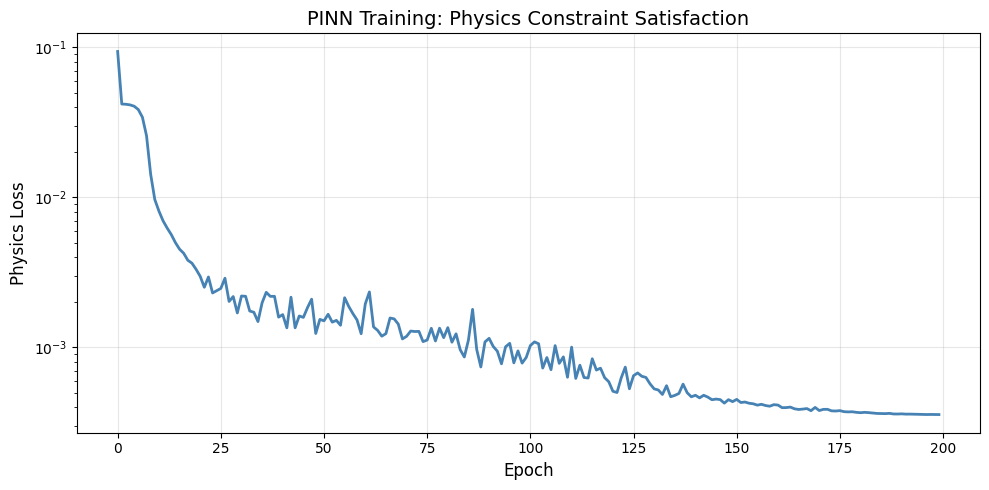

Initial loss: 0.093960
Final loss: 0.000357
Loss reduction: 99.6%


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2, color='steelblue')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Physics Loss", fontsize=12)
plt.title("PINN Training: Physics Constraint Satisfaction", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss: {losses[-1]:.6f}")
print(f"Loss reduction: {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")

## Validate Physics Constraints

Test that the trained model respects physics constraints on unseen scenarios.

In [7]:
model.eval()

# Test scenarios covering edge cases
test_scenarios = [
    ("Acidic soil", torch.tensor([[4.5, 1.5, 22.0, 25.0, 70.0, 1.0, 20.0]], dtype=torch.float32).to(DEVICE),
     torch.tensor([[0.8, 0.0, 0.0, 0.2]], dtype=torch.float32).to(DEVICE)),

    ("High nutrient (excess EC)", torch.tensor([[6.5, 2.8, 22.0, 25.0, 70.0, 1.0, 20.0]], dtype=torch.float32).to(DEVICE),
     torch.tensor([[0.0, 0.0, 0.0, 0.2]], dtype=torch.float32).to(DEVICE)),

    ("Dry conditions", torch.tensor([[6.0, 1.5, 22.0, 30.0, 30.0, 2.5, 20.0]], dtype=torch.float32).to(DEVICE),
     torch.tensor([[0.0, 0.0, 0.0, 1.0]], dtype=torch.float32).to(DEVICE)),

    ("Optimal conditions", torch.tensor([[6.0, 1.5, 22.0, 25.0, 65.0, 1.0, 20.0]], dtype=torch.float32).to(DEVICE),
     torch.tensor([[0.0, 0.0, 0.3, 0.3]], dtype=torch.float32).to(DEVICE)),

    ("Add base to pH", torch.tensor([[5.5, 1.5, 22.0, 25.0, 70.0, 1.0, 20.0]], dtype=torch.float32).to(DEVICE),
     torch.tensor([[0.0, 1.0, 0.0, 0.2]], dtype=torch.float32).to(DEVICE)),
]

print("Test Predictions on Physics Scenarios:\n")
for scenario_name, test_state, test_action in test_scenarios:
    with torch.no_grad():
        residual = model(test_state, test_action)

    print(f"Scenario: {scenario_name}")
    print(f"  State (pH, EC, T_air, Hum): {test_state[0, [0,1,3,4]].cpu().numpy()}")
    print(f"  Action (acid, base, nut, fan): {test_action[0].cpu().numpy()}")
    print(f"  Residual: {residual[0].cpu().numpy()}")
    print()

Test Predictions on Physics Scenarios:

Scenario: Acidic soil
  State (pH, EC, T_air, Hum): [ 4.5  1.5 25.  70. ]
  Action (acid, base, nut, fan): [0.8 0.  0.  0.2]
  Residual: [-0.70606     0.2143805   0.6734675   5.509341    4.1414433  -0.11265877
  0.49420494]

Scenario: High nutrient (excess EC)
  State (pH, EC, T_air, Hum): [ 6.5  2.8 25.  70. ]
  Action (acid, base, nut, fan): [0.  0.  0.  0.2]
  Residual: [-0.75421697 -0.03330506  0.6829411   5.7379804   4.9335527  -0.10722701
  0.50630236]

Scenario: Dry conditions
  State (pH, EC, T_air, Hum): [ 6.   1.5 30.  30. ]
  Action (acid, base, nut, fan): [0. 0. 0. 1.]
  Residual: [-1.625838   0.2223801  0.7936295 27.876928  79.600334   1.1390071
  0.9820824]

Scenario: Optimal conditions
  State (pH, EC, T_air, Hum): [ 6.   1.5 25.  65. ]
  Action (acid, base, nut, fan): [0.  0.  0.3 0.3]
  Residual: [-0.82076764 -0.9356559   0.7151773   7.593405   11.632458    0.06127408
  0.58774585]

Scenario: Add base to pH
  State (pH, EC, T_air

## Save Trained Model Weights

Save the trained PINN checkpoint for use in the simulator.

In [11]:
CHECKPOINT_PATH = "/content/residual_physics.pt"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": EPOCHS,
    "final_loss": losses[-1],
    "state_dim": 7,
    "action_dim": 4,
}

torch.save(checkpoint, CHECKPOINT_PATH)
print(f"✓ Model saved to: {CHECKPOINT_PATH}")
print(f"  File size: {Path(CHECKPOINT_PATH).stat().st_size / 1024:.1f} KB")
print(f"\nThe simulator will load this automatically on next startup!")

✓ Model saved to: /content/residual_physics.pt
  File size: 71.2 KB

The simulator will load this automatically on next startup!


## Summary

✅ **Physics-Informed Neural Network Trained**

This PINN learned residual corrections to crop physics equations by minimizing physics constraint violations rather than fitting empirical data.

**What the network learned:**
- How to correct pH dynamics: $\delta pH = f(state, action)$
- How to correct EC dynamics: $\delta EC = f(state, action)$
- How to correct air temperature response: $\delta T_{air} = f(state, action)$
- How to correct humidity dynamics: $\delta humidity = f(state, action)$
- How to correct biomass growth: $\delta biomass = f(state, action)$

**Physics constraints enforced:**
- Valid pH range: [4.0, 7.5]
- Valid EC range: [0.1, 3.0]
- VPD non-negativity
- Biomass positivity
- Nutrient-EC sensitivity
- Fan speed consistency

**Checkpoint:** `residual_physics.pt` saved and ready for simulator loading.

The simulator (`DigitalTwin`) will automatically load these trained weights on next startup!